In [1]:
# 4.1

x = [1, 2, 3, 10]
y = [10, 20, 30, 40]
sum1 = []

# Making the zip sum
for i, j in zip(x, y):                 
    sum1.append(i + j) 

# Making it a one liner using zip
sum2 = [i + j for i, j in zip(x, y)]

# Using function map (we need to define the sum function)
def SUM(x, y):
    sum3 = x + y
    return sum3
 
sum3 = list(map(SUM, x, y))

print(sum1)
print(sum2)
print(sum3)

[11, 22, 33, 50]
[11, 22, 33, 50]
[11, 22, 33, 50]


In [2]:
# 4.3

import numpy as np

def who_wins(user, comp):

    if user == comp:
        return print("It's a tie! Try again! Maybe you will win.")
        
    if user == "R":
        if comp == "S":
            return print("You win! YAYAYAYAYAYAY")
        else:
            return print("You lose. Awh man :(")
        
    elif user == "P":
        if comp == "R":
            return print("You win! YAYAYAYAYAYAY")
        else:
            return print("You lose. Awh man :(")
        
    elif user == "S":
        if comp == "P":
            return print("You win! YAYAYAYAYAYAY")
        else:
            return print("You lose. Awh man :(")

# Starting the game
print("Let's play Rock Paper Scissors!!!")
print("Use R for Rock, P for Paper, S for Scissors.")
print()

user_choice = input("3! 2! 1! Choose now! (R/P/S)? ")

# Making the random computer choice
options = ["R", "P", "S"]
comp_choice = np.random.choice(options)

# Checking if the input is valid
if user_choice not in ["R", "P", "S"]:
    print("Nuh-uh, try again please! Type R, P, or S.")

else:
    a = who_wins(user_choice, comp_choice)

Let's play Rock Paper Scissors!!!
Use R for Rock, P for Paper, S for Scissors.

3! 2! 1! Choose now! (R/P/S)? R
You win! YAYAYAYAYAYAY


Sample mean: 184.96895650893924
Sample std: 8.013901082078187


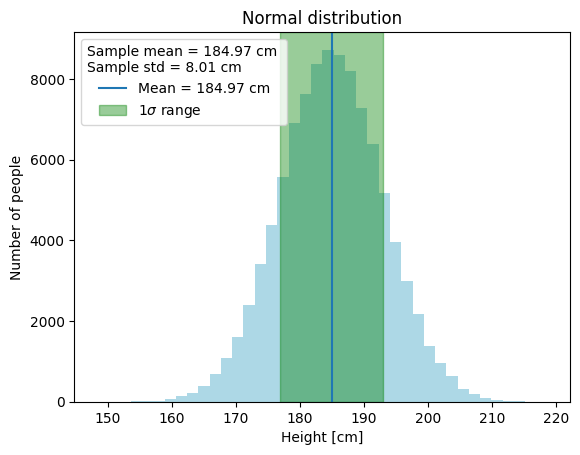

Probablity X is smaller than h = 180 cm is 26.7615
Probablity for x within one sigma is 68.27


In [3]:
# 4.4

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

# Generating data for 100000 human lengths, with average height of 185 and standard deviation of 8.
lengths = np.random.normal(185, 8, 100000)

# Making the sample mean and standard deviation
miu = np.mean(lengths)
sigma = np.std(lengths)

print("Sample mean:", miu)
print("Sample std:", sigma)

# Making the histogram
plt.figure()
plt.hist(lengths, bins=40, color="lightblue")

# Plotting the vertical line at the mean and shading the required area
plt.axvline(miu, label=f"Mean = {miu:.2f} cm")

left_edge = miu - sigma  
right_edge = miu + sigma

plt.axvspan(
    left_edge, right_edge,     
    alpha=0.4,                 
    color='green',
    label=r"1$\sigma$ range"
)

# The legend with the formulas
plt.legend(title=f"Sample mean = {miu:.2f} cm \nSample std = {sigma:.2f} cm")

plt.xlabel("Height [cm]")
plt.ylabel("Number of people")
plt.title("Normal distribution")

plt.show()

# Using the scipy.stats.norm.cdf for probabilities
h = 180.0 
p_h = scipy.stats.norm.cdf(h, loc = miu, scale = sigma) * 100
print(f"Probablity X is smaller than h = 180 cm is {p_h:.4f}")

lower = 193
upper = 177

a = scipy.stats.norm.cdf(upper, loc=185, scale=8)
b = scipy.stats.norm.cdf(lower, loc=185, scale=8)

p_sigma = abs(a - b) * 100

print(f"Probablity for x within one sigma is {p_sigma:.2f}")

In [4]:
# 4.6

import numpy as np
from numpy import sin, cos, tan, log, log10

# Asking for user input for the funtion and boundaries
function = input("Enter a function f(x) = ")
a = eval(input("Enter a value for the lower boundary: "))
b = eval(input("Enter a value for the upper boundary: "))
N = 1000000

# Calculating the final value using Monte Carlo
x = np.random.uniform(a, b, N) 
y = eval(function)
value = ((b-a) / N) * sum(y)

# Printing the value to check it is ok
print(value)

Enter a function f(x) = x
Enter a value for the lower boundary: 0
Enter a value for the upper boundary: 1
0.49989564419162874


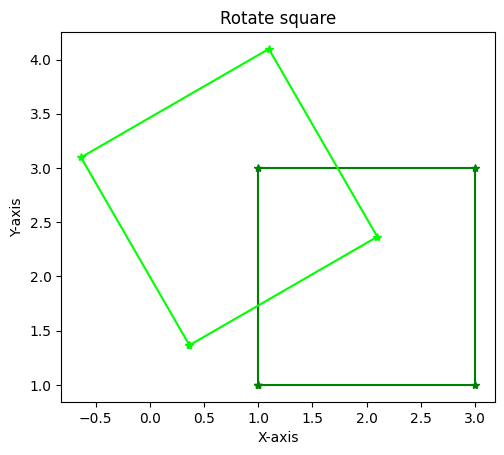

In [6]:
# 4.12 

import numpy as np
from numpy import sin, cos
import matplotlib.pyplot as plt

# Transforming from degrees to radians
tht = 30
rad = np.radians(tht)

# The given data for the square
x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

# Using the rotation formula so we can rotate the square
rotor = cos(rad) + 1j*sin(rad)
xy = rotor * (x + 1j*y)

# Making the plot
plt.plot(x, y, marker='*', color='green')
plt.plot(xy.real, xy.imag, marker='*', color='lime')
plt.title("Rotate square")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.gca().set_aspect(1)
plt.show()

In [7]:
# 4.14

import numpy as np

# Making the function filter
def funcfilter(func, seq):
    
    newlist = []
    npseq = np.asarray(seq)
    
    # Filtering the sequence
    for i in range(len(npseq)):
        if npseq[i] > 0:
            newlist.append(npseq[i])
            
    result = func(newlist)
    return result

sq = np.array([-100, -10, 0, 10, 100])
result1 = funcfilter(np.log10, sq)

# Printing the results
print("Result log10:", result1)

# result2 = funcfilter(np.log10, 100)
# For just a number we get an error bc len() of unsized object 

Result log10: [1. 2.]


In [16]:
# 4.16

import scipy
from astropy.cosmology import Planck18

# The given constants
H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

# Defining the function to use in the integration
# I convert H0 to m and then the final answer in Gyr
def function(z):
    func = (1/((1+z)*(3.240779289E-20 * H0 * (Om0*((1+z)**3) + Ode0)**0.5)))/ 3.15E+16
    return func

# Using scipy.integrate.quad with z = 2
a = scipy.integrate.quad(function,0,2)
value, error = a

# Printing the final value
print(f"For z = 2, the amount in Gyrs for the lookback time is {value:.2f}")

For z = 2, the amount in Gyrs for the lookback time is 10.55


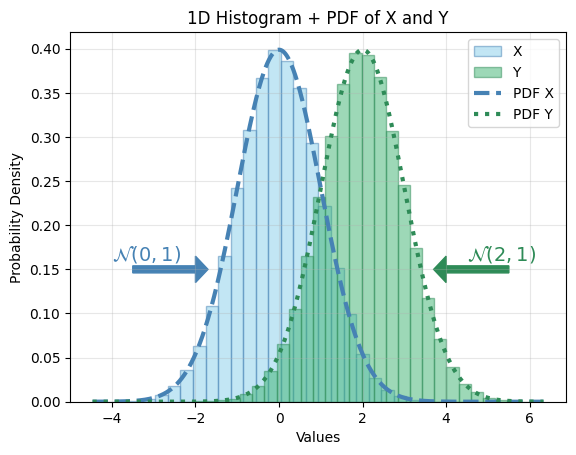

In [13]:
# 4.21 part 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

# Histograms
plt.hist(X, bins=30, color="skyblue", alpha = 0.5, 
         edgecolor = "steelblue", density=True, label='X')
plt.hist(Y, bins=30, color="mediumseagreen", alpha = 0.5, 
         edgecolor = "seagreen", density=True, label='Y')

# PDF
vmin = min(X.min(), Y.min())
vmax = max(X.max(), Y.max())
vals = np.linspace(vmin, vmax, 1000)

pdf_X = norm.pdf(vals, 0, 1)
pdf_Y = norm.pdf(vals, 2, 1)

plt.plot(vals, pdf_X, color='steelblue', lw=3, ls='--', label='PDF X')
plt.plot(vals, pdf_Y, color='seagreen', lw=3, ls=':', label='PDF Y')

# Arrow for X (pointing right)
plt.arrow(-3.5, 0.15,   # start position
          1.5, 0,       # dx, dy
          width=0.008,
          head_width=0.03,
          head_length=0.3,
          fc='steelblue',
          ec='steelblue')

plt.text(-4, 0.16,
         r'$\mathcal{N}(0,1)$',
         fontsize=14,
         color='steelblue')

# Arrow for Y (pointing left)
plt.arrow(5.5, 0.15,
          -1.5, 0,
          width=0.008,
          head_width=0.03,
          head_length=0.3,
          fc='seagreen',
          ec='seagreen')

plt.text(4.5, 0.16,
         r'$\mathcal{N}(2,1)$',
         fontsize=14,
         color='seagreen')

plt.title('1D Histogram + PDF of X and Y')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

0.00415
0.00066
5e-05


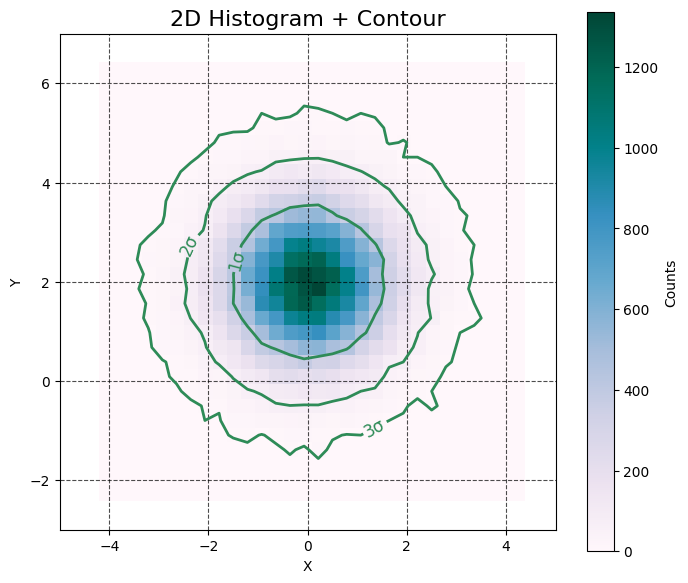

In [5]:
# 4.21 part 2

import numpy as np
import matplotlib.pyplot as plt

# Generate independent standard normal data
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

plt.figure(figsize=(8,7))

# ---- 2D Histogram ----
counts, xedges, yedges = np.histogram2d(X, Y, bins=30)

# Plot histogram
# plt.imshow() displays a 2D array as an image, where the array values are shown as colors.
# .T flips the axes, origin=lower aligns the image with standard Cartesian coordinates
# Without extent, imshow would just plot the array in index coordinates (0 to N).
plt.imshow(counts.T,
           origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           cmap='PuBuGn')

plt.colorbar(label='Counts')

# ---- Convert counts to probability density ----
pdf = counts / np.sum(counts)

# Flatten and sort to compute cumulative probability
# Flatten the 2D grid into a 1D array
# So the highest probability density bins are first in the list, and the lowest are last.
# This sorting order is crucial because the highest-density bins will form the core 
# of the contours (like the peak of the Gaussian)
pdf_flat = pdf.flatten()
sorted_pdf = np.sort(pdf_flat)[::-1]   # descending
cumsum_pdf = np.cumsum(sorted_pdf)
# print(sum(sorted_pdf))

# Find density thresholds for 1σ, 2σ, 3σ
levels = []
for p in [0.683, 0.95, 0.997]:
    idx = np.where(cumsum_pdf >= p)[0][0]
    levels.append(sorted_pdf[idx])
    print(sorted_pdf[idx])

levels = sorted(levels)   # must be increasing for contour()

# ---- Contour from histogram density ----
# np.meshgrid takes 1D arrays of x and y points and returns 2D arrays (Xc, Yc)
# xedges[:-1] means all edges except the last one (start of each bin)
# xedges[1:] means all edges except the first one (end of each bin

xcenters = 0.5*(xedges[:-1] + xedges[1:])
ycenters = 0.5*(yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xcenters, ycenters)

contours = plt.contour(Xc, Yc, pdf.T,
                       levels=levels,
                       colors='seagreen',
                       linewidths=2)

plt.clabel(contours, inline=True, fontsize=12,
           fmt={levels[0]:'3σ',
                levels[1]:'2σ',
                levels[2]:'1σ'})

# ---- Styling like your image ----
plt.title('2D Histogram + Contour', fontsize=16)
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(linestyle='--', color='black', alpha=0.7)

plt.xlim(-5, 5)
plt.ylim(-3, 7)

plt.show()